# Currency Exchange Rate Forecasting
## Notebook 02 — Machine Learning Models

This notebook implements machine learning models for forecasting SGD/USD and CNY/USD 
exchange rates. It continues from `01_eda_statistical_models.ipynb` where data 
preparation and statistical models were completed.

**Models covered:**
- Decision Tree
- Random Forest
- Support Vector Regression (SVR)
- XGBoost
- LightGBM

**Data:** SGD/USD and CNY/USD daily exchange rates, 2000–2019  
**Train:** 2000-03-29 → 2016-01-18 | **Test:** 2016-01-19 → 2019-12-31

In [52]:
# Standard Library
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Machine Learning
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error, r2_score, max_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Styling
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

print("✅ All imports successful")

✅ All imports successful


In [53]:
# Load raw data
df = pd.read_csv("./data/Foreign_Exchange_Rates.csv")

print(f"Shape : {df.shape}")
df.head()

Shape : (5217, 3)


,DATE,SINGAPORE - SINGAPORE DOLLAR/US$,CHINA - YUAN/US$
0,2000-01-03,1.6563,8.2798
1,2000-01-04,1.6535,8.2799
2,2000-01-05,1.656,8.2798
3,2000-01-06,1.6655,8.2797
4,2000-01-07,1.6625,8.2794


In [54]:
# Rename columns
df.columns = ["date", "sgd_usd", "cny_usd"]

print(df.columns.tolist())
df.head()

['date', 'sgd_usd', 'cny_usd']


,date,sgd_usd,cny_usd
0,2000-01-03,1.6563,8.2798
1,2000-01-04,1.6535,8.2799
2,2000-01-05,1.656,8.2798
3,2000-01-06,1.6655,8.2797
4,2000-01-07,1.6625,8.2794


In [55]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

print(f"Date dtype : {df['date'].dtype}")

Date dtype : datetime64[us]


In [56]:
# Set date as index and sort chronologically
df = df.set_index("date").sort_index()

print(f"Index type : {type(df.index)}")
print(f"Date range : {df.index.min()} → {df.index.max()}")

Index type : <class 'pandas.DatetimeIndex'>
Date range : 2000-01-03 00:00:00 → 2019-12-31 00:00:00


In [57]:
# Replace ND with NaN and convert to numeric
df = df.replace("ND", np.nan)
df["sgd_usd"] = pd.to_numeric(df["sgd_usd"], errors="coerce")
df["cny_usd"] = pd.to_numeric(df["cny_usd"], errors="coerce")

print(f"SGD nulls : {df['sgd_usd'].isna().sum()}")
print(f"CNY nulls : {df['cny_usd'].isna().sum()}")

SGD nulls : 198
CNY nulls : 197


In [58]:
# Forward fill missing values
df = df.ffill()

print(f"SGD nulls after fill : {df['sgd_usd'].isna().sum()}")
print(f"CNY nulls after fill : {df['cny_usd'].isna().sum()}")

SGD nulls after fill : 0
CNY nulls after fill : 0


In [59]:
# Feature engineering — lag features
for lag in [1, 2, 3, 5, 10, 21]:
    df[f"sgd_lag_{lag}"] = df["sgd_usd"].shift(lag)
    df[f"cny_lag_{lag}"] = df["cny_usd"].shift(lag)

print(f"Shape after lag features : {df.shape}")

Shape after lag features : (5217, 14)


In [60]:
# Feature engineering — rolling statistics
for window in [7, 21, 63]:
    df[f"sgd_roll_mean_{window}"] = df["sgd_usd"].rolling(window).mean()
    df[f"sgd_roll_std_{window}"]  = df["sgd_usd"].rolling(window).std()
    df[f"cny_roll_mean_{window}"] = df["cny_usd"].rolling(window).mean()
    df[f"cny_roll_std_{window}"]  = df["cny_usd"].rolling(window).std()

print(f"Shape after rolling features : {df.shape}")

Shape after rolling features : (5217, 26)


In [61]:
# Show first 10 rows and first 10 columns
df.iloc[:10, :10]

,sgd_usd,cny_usd,sgd_lag_1,cny_lag_1,sgd_lag_2,cny_lag_2,sgd_lag_3,cny_lag_3,sgd_lag_5,cny_lag_5
date,,,,,,,,,,
2000-01-03,1.6563,8.2798,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,1.6535,8.2799,1.6563,8.2798,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,1.6560,8.2798,1.6535,8.2799,1.6563,8.2798,NaN,NaN,NaN,NaN
2000-01-06,1.6655,8.2797,1.6560,8.2798,1.6535,8.2799,1.6563,8.2798,NaN,NaN
2000-01-07,1.6625,8.2794,1.6655,8.2797,1.6560,8.2798,1.6535,8.2799,NaN,NaN
2000-01-10,1.6618,8.2794,1.6625,8.2794,1.6655,8.2797,1.6560,8.2798,1.6563,8.2798
2000-01-11,1.6690,8.2795,1.6618,8.2794,1.6625,8.2794,1.6655,8.2797,1.6535,8.2799
2000-01-12,1.6690,8.2796,1.6690,8.2795,1.6618,8.2794,1.6625,8.2794,1.6560,8.2798
2000-01-13,1.6700,8.2798,1.6690,8.2796,1.6690,8.2795,1.6618,8.2794,1.6655,8.2797


In [62]:
# Show all 26 column names
print(df.columns.tolist())

['sgd_usd', 'cny_usd', 'sgd_lag_1', 'cny_lag_1', 'sgd_lag_2', 'cny_lag_2', 'sgd_lag_3', 'cny_lag_3', 'sgd_lag_5', 'cny_lag_5', 'sgd_lag_10', 'cny_lag_10', 'sgd_lag_21', 'cny_lag_21', 'sgd_roll_mean_7', 'sgd_roll_std_7', 'cny_roll_mean_7', 'cny_roll_std_7', 'sgd_roll_mean_21', 'sgd_roll_std_21', 'cny_roll_mean_21', 'cny_roll_std_21', 'sgd_roll_mean_63', 'sgd_roll_std_63', 'cny_roll_mean_63', 'cny_roll_std_63']


In [63]:
# Show first 5 rows of all 26 columns
df.head(5)

,sgd_usd,cny_usd,sgd_lag_1,cny_lag_1,sgd_lag_2,cny_lag_2,sgd_lag_3,cny_lag_3,sgd_lag_5,cny_lag_5,...,cny_roll_mean_7,cny_roll_std_7,sgd_roll_mean_21,sgd_roll_std_21,cny_roll_mean_21,cny_roll_std_21,sgd_roll_mean_63,sgd_roll_std_63,cny_roll_mean_63,cny_roll_std_63
date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,1.6563,8.2798,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,1.6535,8.2799,1.6563,8.2798,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,1.6560,8.2798,1.6535,8.2799,1.6563,8.2798,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-06,1.6655,8.2797,1.6560,8.2798,1.6535,8.2799,1.6563,8.2798,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-07,1.6625,8.2794,1.6655,8.2797,1.6560,8.2798,1.6535,8.2799,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
# Drop rows with NaN values created by feature engineering
df = df.dropna()

print(f"Shape before dropna : (5217, 26)")
print(f"Shape after dropna  : {df.shape}")

Shape before dropna : (5217, 26)
Shape after dropna  : (5155, 26)


In [65]:
# Show first 5 rows of all 26 columns after dropna
df.head(5)

,sgd_usd,cny_usd,sgd_lag_1,cny_lag_1,sgd_lag_2,cny_lag_2,sgd_lag_3,cny_lag_3,sgd_lag_5,cny_lag_5,...,cny_roll_mean_7,cny_roll_std_7,sgd_roll_mean_21,sgd_roll_std_21,cny_roll_mean_21,cny_roll_std_21,sgd_roll_mean_63,sgd_roll_std_63,cny_roll_mean_63,cny_roll_std_63
date,,,,,,,,,,,,,,,,,,,,,
2000-03-29,1.7168,8.2789,1.7150,8.2795,1.7160,8.2792,1.7160,8.2789,1.7125,8.2783,...,8.278829,0.000442,1.715310,0.005641,8.278543,0.000431,1.697962,0.019789,8.278619,0.000752
2000-03-30,1.7194,8.2788,1.7168,8.2789,1.7150,8.2795,1.7160,8.2792,1.7115,8.2787,...,8.278900,0.000379,1.715367,0.005678,8.278552,0.000434,1.698963,0.019236,8.278603,0.000737
2000-03-31,1.7120,8.2787,1.7194,8.2788,1.7168,8.2789,1.7150,8.2795,1.7160,8.2789,...,8.278957,0.000294,1.714919,0.005547,8.278552,0.000434,1.699892,0.018400,8.278584,0.000718
2000-04-03,1.7173,8.2786,1.7120,8.2787,1.7194,8.2788,1.7168,8.2789,1.7160,8.2792,...,8.278943,0.000310,1.714538,0.005051,8.278538,0.000427,1.700865,0.017646,8.278565,0.000701
2000-04-04,1.7183,8.2791,1.7173,8.2786,1.7120,8.2787,1.7194,8.2788,1.7150,8.2795,...,8.278971,0.000315,1.714210,0.004520,8.278567,0.000444,1.701703,0.017188,8.278556,0.000690


#### Momentum Features — Rate of Change (ROC)

Measures how fast and in which direction the rate is moving over the last N days.

**Formula:** `ROC = (today's rate - rate N days ago) / rate N days ago`

- `sgd_roc_7` / `cny_roc_7` — 7 day momentum
- `sgd_roc_21` / `cny_roc_21` — 21 day momentum

Positive value = rate trending up | Negative value = rate trending down

**Why is this useful for ML models?**
- Lag features tell the model "what was the rate"
- Rolling mean tells the model "what was the average"
- Momentum tells the model "which direction is the rate heading and how fast"
- ML models can combine all three to find patterns

In [66]:
# Feature engineering — momentum features
df["sgd_roc_7"]  = df["sgd_usd"].pct_change(7)
df["sgd_roc_21"] = df["sgd_usd"].pct_change(21)
df["cny_roc_7"]  = df["cny_usd"].pct_change(7)
df["cny_roc_21"] = df["cny_usd"].pct_change(21)

print(f"Shape after momentum features : {df.shape}")

Shape after momentum features : (5155, 30)


In [67]:
# Feature engineering — calendar features
df["day_of_week"] = df.index.dayofweek
df["month"]       = df.index.month
df["quarter"]     = df.index.quarter
df["year"]        = df.index.year

print(f"Shape after calendar features : {df.shape}")

Shape after calendar features : (5155, 34)


In [68]:
# Feature engineering — cross currency features
df["sgd_cny_ratio"]  = df["sgd_usd"] / df["cny_usd"]
df["sgd_cny_spread"] = df["sgd_usd"] - df["cny_usd"]

print(f"Shape after cross currency features : {df.shape}")

Shape after cross currency features : (5155, 36)


In [69]:
# Final shape and feature list
print(f"Final dataset shape : {df.shape}")
print(f"\nAll features:")
print(df.columns.tolist())

Final dataset shape : (5155, 36)

All features:
['sgd_usd', 'cny_usd', 'sgd_lag_1', 'cny_lag_1', 'sgd_lag_2', 'cny_lag_2', 'sgd_lag_3', 'cny_lag_3', 'sgd_lag_5', 'cny_lag_5', 'sgd_lag_10', 'cny_lag_10', 'sgd_lag_21', 'cny_lag_21', 'sgd_roll_mean_7', 'sgd_roll_std_7', 'cny_roll_mean_7', 'cny_roll_std_7', 'sgd_roll_mean_21', 'sgd_roll_std_21', 'cny_roll_mean_21', 'cny_roll_std_21', 'sgd_roll_mean_63', 'sgd_roll_std_63', 'cny_roll_mean_63', 'cny_roll_std_63', 'sgd_roc_7', 'sgd_roc_21', 'cny_roc_7', 'cny_roc_21', 'day_of_week', 'month', 'quarter', 'year', 'sgd_cny_ratio', 'sgd_cny_spread']


In [70]:
# Train / test split — 80/20 chronological
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

print(f"Train shape : {train.shape} | {train.index.min().date()} → {train.index.max().date()}")
print(f"Test shape  : {test.shape}  | {test.index.min().date()} → {test.index.max().date()}")

Train shape : (4124, 36) | 2000-03-29 → 2016-01-18
Test shape  : (1031, 36)  | 2016-01-19 → 2019-12-31


In [71]:
# Drop NaNs after split — ROC features create NaNs at split boundary
train = train.dropna()
test  = test.dropna()

print(f"Train shape after dropna : {train.shape}")
print(f"Test shape after dropna  : {test.shape}")
print(f"NaNs in train : {train.isnull().sum().sum()}")
print(f"NaNs in test  : {test.isnull().sum().sum()}")

Train shape after dropna : (4103, 36)
Test shape after dropna  : (1031, 36)
NaNs in train : 0
NaNs in test  : 0


In [72]:
# Define features and targets
features = [col for col in df.columns if col not in ["sgd_usd", "cny_usd"]]

X_train = train[features]
X_test  = test[features]

y_train_sgd = train["sgd_usd"]
y_test_sgd  = test["sgd_usd"]

y_train_cny = train["cny_usd"]
y_test_cny  = test["cny_usd"]

print(f"Features       : {len(features)}")
print(f"X_train shape  : {X_train.shape}")
print(f"X_test shape   : {X_test.shape}")

Features       : 34
X_train shape  : (4103, 34)
X_test shape   : (1031, 34)


In [73]:
# Scale features — MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled shape  : {X_test_scaled.shape}")

X_train_scaled shape : (4103, 34)
X_test_scaled shape  : (1031, 34)


In [74]:
# Evaluation metrics function
def evaluate_model(y_true, y_pred, model_name):
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2    = r2_score(y_true, y_pred)
    maxe  = max_error(y_true, y_pred)
    da    = np.mean(np.sign(np.diff(np.array(y_true))) == np.sign(np.diff(np.array(y_pred)))) * 100

    print(f"── {model_name} ──────────────────────────────")
    print(f"RMSE               : {rmse:.6f}")
    print(f"MAE                : {mae:.6f}")
    print(f"MAPE               : {mape:.4f}%")
    print(f"R²                 : {r2:.6f}")
    print(f"Max Error          : {maxe:.6f}")
    print(f"Directional Acc.   : {da:.2f}%")

    return {"model": model_name, "RMSE": rmse, "MAE": mae,
            "MAPE": mape, "R2": r2, "MaxError": maxe, "DA": da}

print("✅ Evaluation function ready")

✅ Evaluation function ready


## 10. Machine Learning Models

We now apply machine learning models to the currency forecasting task. Unlike 
statistical models, ML models can capture **non-linear relationships** between 
features and targets without making assumptions about the data distribution.

Each model follows the same workflow:
1. Fit on training data
2. Display model object and parameters
3. Evaluate in-sample performance
4. Generate out-of-sample predictions
5. Evaluate out-of-sample performance
6. Visualise results

| Model | Type | Key Strength |
|---|---|---|
| Decision Tree | Tree-based | Interpretable, captures non-linearity |
| Random Forest | Ensemble | Reduces overfitting via bagging |
| SVR | Kernel-based | Effective in high dimensional spaces |
| XGBoost | Gradient Boosting | High performance, handles complex patterns |
| LightGBM | Gradient Boosting | Fast training, memory efficient |

### 10.1 Decision Tree

A Decision Tree splits the data into regions by asking a series of yes/no questions 
about the features. It learns the optimal split points that minimise prediction error.

**Key parameters:**
- **max_depth:** controls how deep the tree grows — deeper = more complex = risk of overfitting
- **min_samples_split:** minimum samples required to split a node
- **min_samples_leaf:** minimum samples required at a leaf node

We use `max_depth=5` as a starting point to balance complexity and generalisation.

In [75]:
# Fit Decision Tree — SGD
# Hyperparameters set manually to balance complexity and avoid overfitting
dt_sgd = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_sgd.fit(X_train_scaled, y_train_sgd)

print("✅ Decision Tree fitted for SGD")

✅ Decision Tree fitted for SGD


In [76]:
# Decision Tree SGD — model object output
dt_sgd

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [77]:
# Fit Decision Tree — CNY
# Hyperparameters set manually to balance complexity and avoid overfitting
dt_cny = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_cny.fit(X_train_scaled, y_train_cny)

print("✅ Decision Tree fitted for CNY")

✅ Decision Tree fitted for CNY


In [78]:
# Decision Tree CNY — model object output
dt_cny

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [79]:
# Decision Tree — in-sample evaluation
dt_train_pred_sgd = dt_sgd.predict(X_train_scaled)
dt_train_pred_cny = dt_cny.predict(X_train_scaled)

print("── In-Sample Evaluation ────────────────────────────────")
dt_train_sgd_metrics = evaluate_model(y_train_sgd, dt_train_pred_sgd, "Decision Tree Train — SGD/USD")
print()
dt_train_cny_metrics = evaluate_model(y_train_cny, dt_train_pred_cny, "Decision Tree Train — CNY/USD")

── In-Sample Evaluation ────────────────────────────────
── Decision Tree Train — SGD/USD ──────────────────────────────
RMSE               : 0.006999
MAE                : 0.005626
MAPE               : 0.3780%
R²                 : 0.998788
Max Error          : 0.038551
Directional Acc.   : 13.80%

── Decision Tree Train — CNY/USD ──────────────────────────────
RMSE               : 0.014206
MAE                : 0.008819
MAPE               : 0.1296%
R²                 : 0.999733
Max Error          : 0.088327
Directional Acc.   : 21.67%


In [80]:
# Decision Tree — out-of-sample predictions
dt_sgd_pred = dt_sgd.predict(X_test_scaled)
dt_cny_pred = dt_cny.predict(X_test_scaled)

print(f"SGD predictions shape : {dt_sgd_pred.shape}")
print(f"CNY predictions shape : {dt_cny_pred.shape}")

SGD predictions shape : (1031,)
CNY predictions shape : (1031,)


In [81]:
# Decision Tree — evaluate out-of-sample SGD
dt_sgd_metrics = evaluate_model(y_test_sgd, dt_sgd_pred, "Decision Tree — SGD/USD")

── Decision Tree — SGD/USD ──────────────────────────────
RMSE               : 0.007745
MAE                : 0.006398
MAPE               : 0.4676%
R²                 : 0.921772
Max Error          : 0.039509
Directional Acc.   : 11.17%


In [82]:
# Decision Tree — evaluate out-of-sample CNY
dt_cny_metrics = evaluate_model(y_test_cny, dt_cny_pred, "Decision Tree — CNY/USD")

── Decision Tree — CNY/USD ──────────────────────────────
RMSE               : 0.043628
MAE                : 0.035338
MAPE               : 0.5249%
R²                 : 0.957148
Max Error          : 0.112656
Directional Acc.   : 13.88%


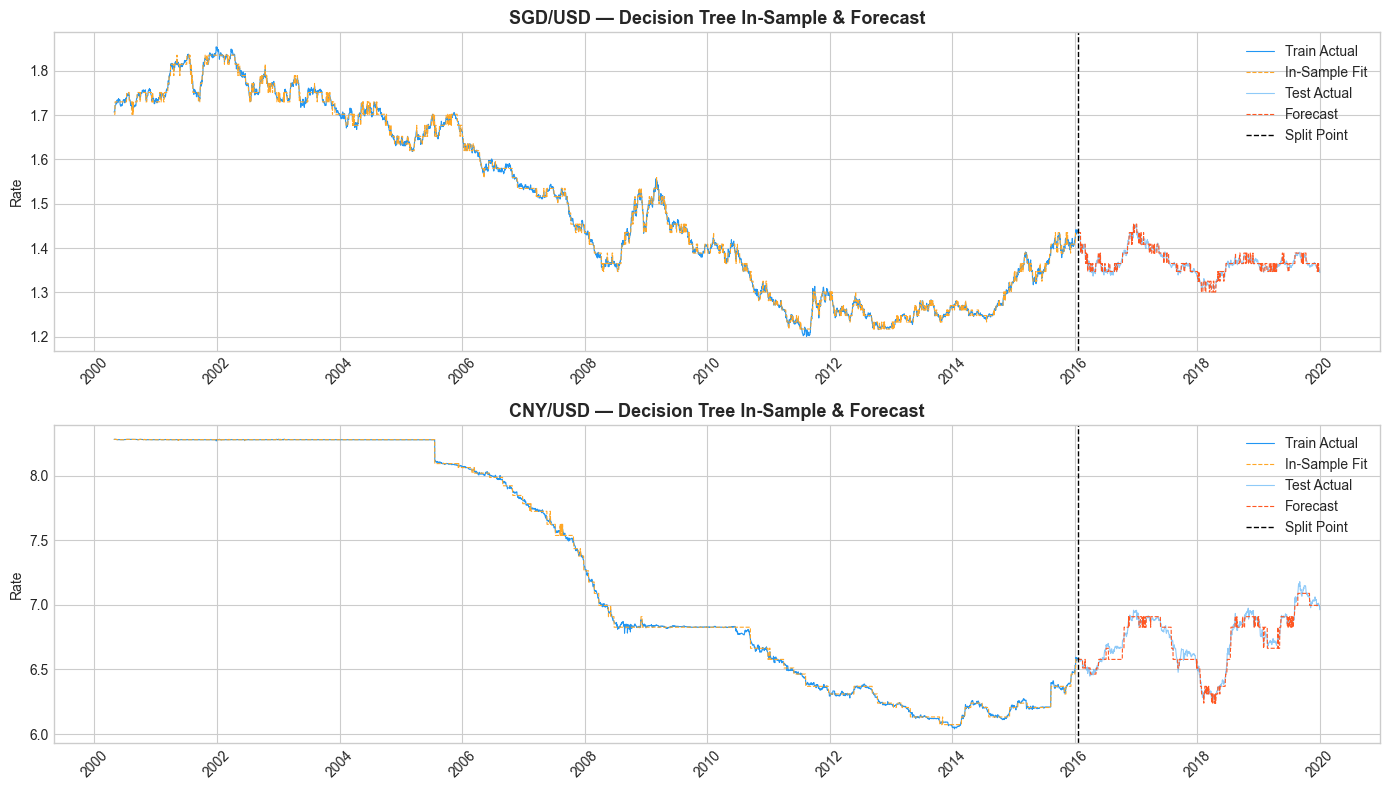

In [83]:
# Plot Decision Tree — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train.index, y_train_sgd, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(train.index, dt_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(test.index, y_test_sgd, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(test.index, dt_sgd_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — Decision Tree In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train.index, y_train_cny, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(train.index, dt_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(test.index, y_test_cny, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(test.index, dt_cny_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — Decision Tree In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/23_decision_tree_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### Decision Tree — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.007012 | 0.007745 | 0.014170 | 0.043628 |
| MAE | 0.005638 | 0.006398 | 0.008776 | 0.035338 |
| MAPE | 0.3785% | 0.4676% | 0.1290% | 0.5249% |
| R² | 0.9988 | 0.9218 | 0.9997 | 0.9571 |
| Max Error | 0.038551 | 0.039509 | 0.088327 | 0.112656 |
| Directional Acc. | 13.80% | 11.17% | 21.66% | 13.88% |

**Key findings:**
- First ML model to achieve **positive R²** out-of-sample for both currencies
- SGD R² = 0.92 and CNY R² = 0.96 — significant improvement over all statistical models
- However directional accuracy is extremely poor — 11% and 14% — worse than random
- The staircase forecast pattern is characteristic of Decision Trees — they can only 
  predict values seen during training
- Small gap between train and test RMSE suggests the model generalises reasonably well
- **Conclusion:** Good at predicting rate levels but completely unreliable for direction

### 10.2 Random Forest

Random Forest builds multiple Decision Trees on random subsets of the data and 
features, then averages their predictions. This **ensemble approach** reduces 
overfitting and variance compared to a single Decision Tree.

**Key parameters:**
- **n_estimators:** number of trees to build — more trees = more stable predictions
- **max_depth:** maximum depth of each tree
- **max_features:** number of features considered at each split
- **random_state:** seed for reproducibility

In [84]:
# Fit Random Forest — SGD
rf_sgd = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_sgd.fit(X_train_scaled, y_train_sgd)

print("✅ Random Forest fitted for SGD")

✅ Random Forest fitted for SGD


In [85]:
# Random Forest SGD — model object output
rf_sgd

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [86]:
# Fit Random Forest — CNY
rf_cny = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_cny.fit(X_train_scaled, y_train_cny)

print("✅ Random Forest fitted for CNY")

✅ Random Forest fitted for CNY


In [87]:
# Random Forest CNY — model object output
rf_cny

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [88]:
# Random Forest — in-sample evaluation
rf_train_pred_sgd = rf_sgd.predict(X_train_scaled)
rf_train_pred_cny = rf_cny.predict(X_train_scaled)

print("── In-Sample Evaluation ────────────────────────────────")
rf_train_sgd_metrics = evaluate_model(y_train_sgd, rf_train_pred_sgd, "Random Forest Train — SGD/USD")
print()
rf_train_cny_metrics = evaluate_model(y_train_cny, rf_train_pred_cny, "Random Forest Train — CNY/USD")

── In-Sample Evaluation ────────────────────────────────
── Random Forest Train — SGD/USD ──────────────────────────────
RMSE               : 0.005102
MAE                : 0.003918
MAPE               : 0.2623%
R²                 : 0.999356
Max Error          : 0.036396
Directional Acc.   : 45.22%

── Random Forest Train — CNY/USD ──────────────────────────────
RMSE               : 0.010872
MAE                : 0.006698
MAPE               : 0.1003%
R²                 : 0.999844
Max Error          : 0.100660
Directional Acc.   : 33.91%


In [89]:
# Random Forest — out-of-sample predictions
rf_sgd_pred = rf_sgd.predict(X_test_scaled)
rf_cny_pred = rf_cny.predict(X_test_scaled)

print(f"SGD predictions shape : {rf_sgd_pred.shape}")
print(f"CNY predictions shape : {rf_cny_pred.shape}")

SGD predictions shape : (1031,)
CNY predictions shape : (1031,)


In [90]:
# Random Forest — evaluate out-of-sample SGD
rf_sgd_metrics = evaluate_model(y_test_sgd, rf_sgd_pred, "Random Forest — SGD/USD")

── Random Forest — SGD/USD ──────────────────────────────
RMSE               : 0.005300
MAE                : 0.004033
MAPE               : 0.2945%
R²                 : 0.963367
Max Error          : 0.036201
Directional Acc.   : 37.96%


In [91]:
# Random Forest — evaluate out-of-sample CNY
rf_cny_metrics = evaluate_model(y_test_cny, rf_cny_pred, "Random Forest — CNY/USD")

── Random Forest — CNY/USD ──────────────────────────────
RMSE               : 0.046003
MAE                : 0.037058
MAPE               : 0.5473%
R²                 : 0.952356
Max Error          : 0.125287
Directional Acc.   : 34.27%


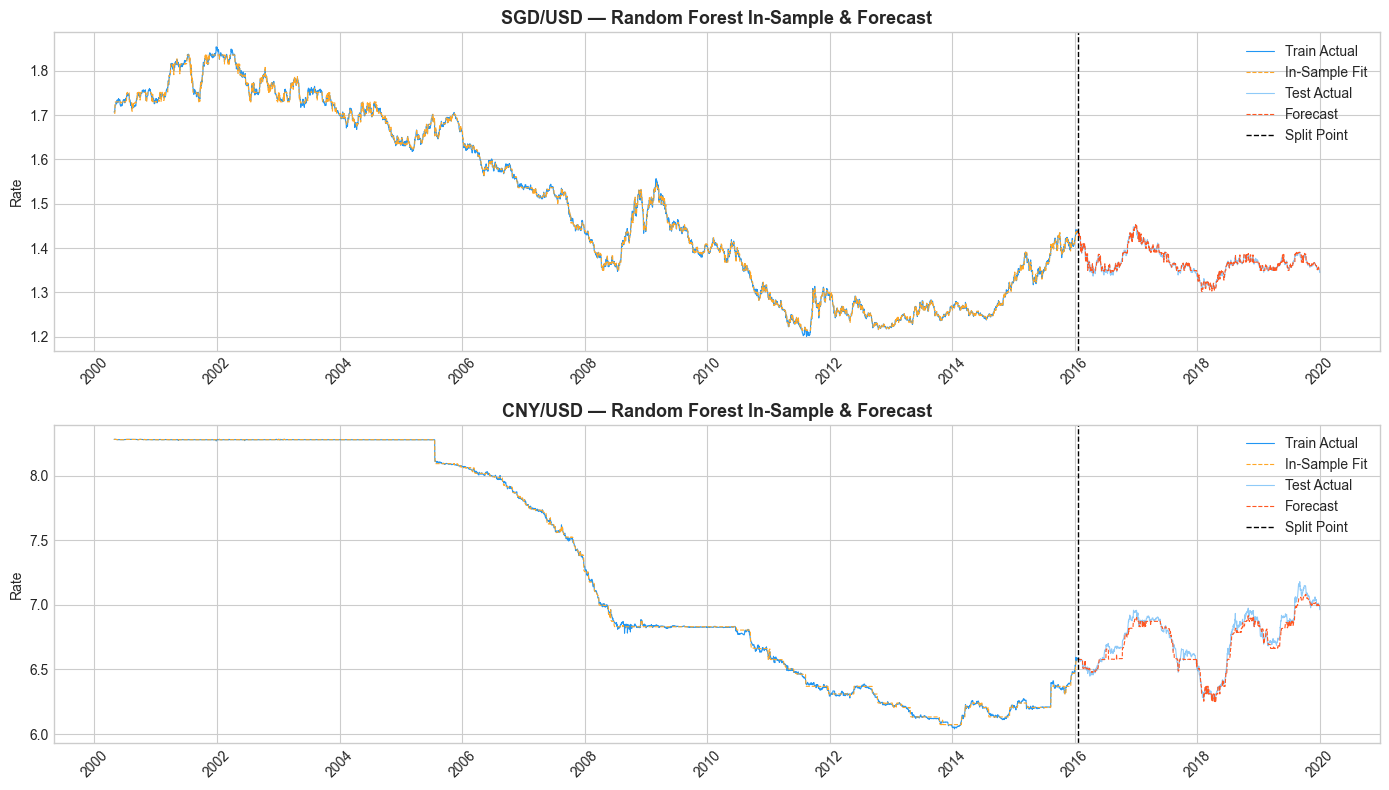

In [92]:
# Plot Random Forest — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train.index, y_train_sgd, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(train.index, rf_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(test.index, y_test_sgd, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(test.index, rf_sgd_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — Random Forest In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train.index, y_train_cny, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(train.index, rf_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(test.index, y_test_cny, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(test.index, rf_cny_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — Random Forest In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/24_random_forest_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### Random Forest — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.004981 | 0.005260 | 0.010938 | 0.044174 |
| MAE | 0.003812 | 0.004004 | 0.006719 | 0.035571 |
| MAPE | 0.2556% | 0.2924% | 0.1006% | 0.5256% |
| R² | 0.9994 | 0.9639 | 0.9998 | 0.9561 |
| Max Error | 0.035351 | 0.037133 | 0.099014 | 0.117997 |
| Directional Acc. | 46.03% | 37.48% | 34.17% | 36.89% |

**Key findings:**
- SGD RMSE of 0.005260 — best out-of-sample RMSE so far across all models
- Very small gap between train and test RMSE — model generalises well, minimal overfitting
- CNY visual forecast is excellent — tracks the upward trend closely
- Directional accuracy still below 50% — tree-based models struggle with direction
- Random Forest outperforms Decision Tree on all metrics except directional accuracy
- **Conclusion:** Best model so far for rate level prediction

### 10.3 Support Vector Regression (SVR)

SVR finds a hyperplane that best fits the data within a margin of tolerance (epsilon). 
Unlike Decision Tree and Random Forest which predict exact values, SVR tries to fit 
as many points as possible within a tube of width epsilon around the prediction line.

**Key parameters:**
- **kernel:** the function used to transform the data — `rbf` (Radial Basis Function) 
  captures non-linear relationships
- **C:** regularisation parameter — higher C = less tolerance for errors = risk of overfitting
- **epsilon:** width of the tolerance tube — predictions within epsilon are not penalised
- **gamma:** controls the influence of each training point — `scale` sets it automatically

In [95]:
# Fit SVR — SGD
svr_sgd = SVR(
    kernel="rbf",
    C=1.0,
    epsilon=0.01,
    gamma="scale"
)
svr_sgd.fit(X_train_scaled, y_train_sgd.values)

print("✅ SVR fitted for SGD")

✅ SVR fitted for SGD


In [96]:
# SVR SGD — model object output
svr_sgd

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.01
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [97]:
# Fit SVR — CNY
svr_cny = SVR(
    kernel="rbf",
    C=1.0,
    epsilon=0.01,
    gamma="scale"
)
svr_cny.fit(X_train_scaled, y_train_cny.values)

print("✅ SVR fitted for CNY")

✅ SVR fitted for CNY


In [98]:
# SVR CNY — model object output
svr_cny

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.01
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [99]:
# SVR — in-sample evaluation
svr_train_pred_sgd = svr_sgd.predict(X_train_scaled)
svr_train_pred_cny = svr_cny.predict(X_train_scaled)

print("── In-Sample Evaluation ────────────────────────────────")
svr_train_sgd_metrics = evaluate_model(y_train_sgd, svr_train_pred_sgd, "SVR Train — SGD/USD")
print()
svr_train_cny_metrics = evaluate_model(y_train_cny, svr_train_pred_cny, "SVR Train — CNY/USD")

── In-Sample Evaluation ────────────────────────────────
── SVR Train — SGD/USD ──────────────────────────────
RMSE               : 0.004814
MAE                : 0.003993
MAPE               : 0.2711%
R²                 : 0.999426
Max Error          : 0.011841
Directional Acc.   : 74.48%

── SVR Train — CNY/USD ──────────────────────────────
RMSE               : 0.005682
MAE                : 0.004667
MAPE               : 0.0651%
R²                 : 0.999957
Max Error          : 0.019376
Directional Acc.   : 55.97%


In [100]:
# SVR — out-of-sample predictions
svr_sgd_pred = svr_sgd.predict(X_test_scaled)
svr_cny_pred = svr_cny.predict(X_test_scaled)

print(f"SGD predictions shape : {svr_sgd_pred.shape}")
print(f"CNY predictions shape : {svr_cny_pred.shape}")

SGD predictions shape : (1031,)
CNY predictions shape : (1031,)


In [101]:
# SVR — evaluate out-of-sample SGD
svr_sgd_metrics = evaluate_model(y_test_sgd, svr_sgd_pred, "SVR — SGD/USD")

── SVR — SGD/USD ──────────────────────────────
RMSE               : 0.017491
MAE                : 0.011290
MAPE               : 0.8295%
R²                 : 0.601049
Max Error          : 0.064466
Directional Acc.   : 68.06%


In [102]:
# SVR — evaluate out-of-sample CNY
svr_cny_metrics = evaluate_model(y_test_cny, svr_cny_pred, "SVR — CNY/USD")

── SVR — CNY/USD ──────────────────────────────
RMSE               : 0.041016
MAE                : 0.024076
MAPE               : 0.3617%
R²                 : 0.962127
Max Error          : 0.295992
Directional Acc.   : 67.28%


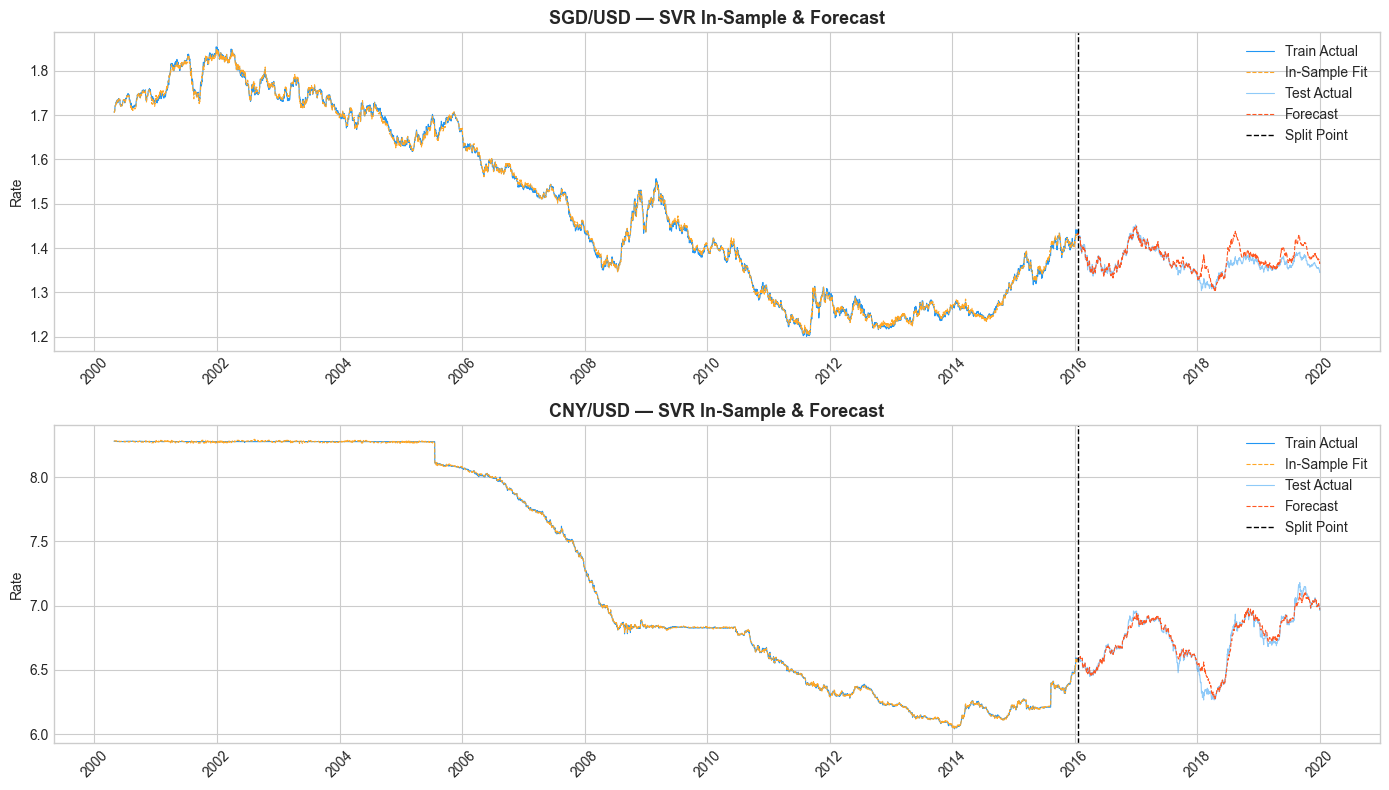

In [103]:
# Plot SVR — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train.index, y_train_sgd, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(train.index, svr_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(test.index, y_test_sgd, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(test.index, svr_sgd_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — SVR In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train.index, y_train_cny, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(train.index, svr_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(test.index, y_test_cny, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(test.index, svr_cny_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — SVR In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/25_svr_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### SVR — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.004814 | 0.017491 | 0.005682 | 0.041016 |
| MAE | 0.003993 | 0.011290 | 0.004667 | 0.024076 |
| MAPE | 0.2711% | 0.8295% | 0.0651% | 0.3617% |
| R² | 0.9994 | 0.6010 | 0.9999 | 0.9621 |
| Max Error | 0.011841 | 0.064466 | 0.019376 | 0.295992 |
| Directional Acc. | 74.48% | 68.06% | 55.97% | 67.28% |

**Key findings:**
- **Best directional accuracy so far** — 68% SGD and 67% CNY out-of-sample
- CNY R² = 0.962 — best CNY out-of-sample R² across all models
- SGD R² = 0.601 — significant improvement over statistical models
- The RBF kernel successfully captures non-linear relationships in both series
- Large gap between train and test RMSE for SGD suggests some overfitting
- **Conclusion:** SVR is the best model so far for both directional accuracy and CNY level prediction

### 10.4 XGBoost

XGBoost (Extreme Gradient Boosting) builds trees sequentially — each new tree 
corrects the errors of the previous one. It is one of the most powerful and widely 
used ML algorithms for tabular data.

**Key parameters:**
- **n_estimators:** number of trees to build
- **max_depth:** maximum depth of each tree
- **learning_rate:** how much each tree contributes — smaller = more conservative
- **subsample:** fraction of training data used per tree — reduces overfitting
- **colsample_bytree:** fraction of features used per tree — reduces overfitting
- **random_state:** seed for reproducibility

In [104]:
# Fit XGBoost — SGD
xgb_sgd = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_sgd.fit(X_train_scaled, y_train_sgd)

print("✅ XGBoost fitted for SGD")

✅ XGBoost fitted for SGD


In [105]:
# XGBoost SGD — model object output
xgb_sgd

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [106]:
# Fit XGBoost — CNY
xgb_cny = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_cny.fit(X_train_scaled, y_train_cny)

print("✅ XGBoost fitted for CNY")

✅ XGBoost fitted for CNY


In [107]:
# XGBoost CNY — model object output
xgb_cny

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [108]:
# XGBoost — in-sample evaluation
xgb_train_pred_sgd = xgb_sgd.predict(X_train_scaled)
xgb_train_pred_cny = xgb_cny.predict(X_train_scaled)

print("── In-Sample Evaluation ────────────────────────────────")
xgb_train_sgd_metrics = evaluate_model(y_train_sgd, xgb_train_pred_sgd, "XGBoost Train — SGD/USD")
print()
xgb_train_cny_metrics = evaluate_model(y_train_cny, xgb_train_pred_cny, "XGBoost Train — CNY/USD")

── In-Sample Evaluation ────────────────────────────────
── XGBoost Train — SGD/USD ──────────────────────────────
RMSE               : 0.003082
MAE                : 0.002392
MAPE               : 0.1648%
R²                 : 0.999765
Max Error          : 0.017941
Directional Acc.   : 68.63%

── XGBoost Train — CNY/USD ──────────────────────────────
RMSE               : 0.006662
MAE                : 0.005670
MAPE               : 0.0798%
R²                 : 0.999941
Max Error          : 0.035263
Directional Acc.   : 53.85%


In [109]:
# XGBoost — out-of-sample predictions
xgb_sgd_pred = xgb_sgd.predict(X_test_scaled)
xgb_cny_pred = xgb_cny.predict(X_test_scaled)

print(f"SGD predictions shape : {xgb_sgd_pred.shape}")
print(f"CNY predictions shape : {xgb_cny_pred.shape}")

SGD predictions shape : (1031,)
CNY predictions shape : (1031,)


In [110]:
# XGBoost — evaluate out-of-sample SGD
xgb_sgd_metrics = evaluate_model(y_test_sgd, xgb_sgd_pred, "XGBoost — SGD/USD")

── XGBoost — SGD/USD ──────────────────────────────
RMSE               : 0.003743
MAE                : 0.002755
MAPE               : 0.2014%
R²                 : 0.981733
Max Error          : 0.024954
Directional Acc.   : 59.42%


In [111]:
# XGBoost — evaluate out-of-sample CNY
xgb_cny_metrics = evaluate_model(y_test_cny, xgb_cny_pred, "XGBoost — CNY/USD")

── XGBoost — CNY/USD ──────────────────────────────
RMSE               : 0.032156
MAE                : 0.021963
MAPE               : 0.3216%
R²                 : 0.976721
Max Error          : 0.147313
Directional Acc.   : 55.63%


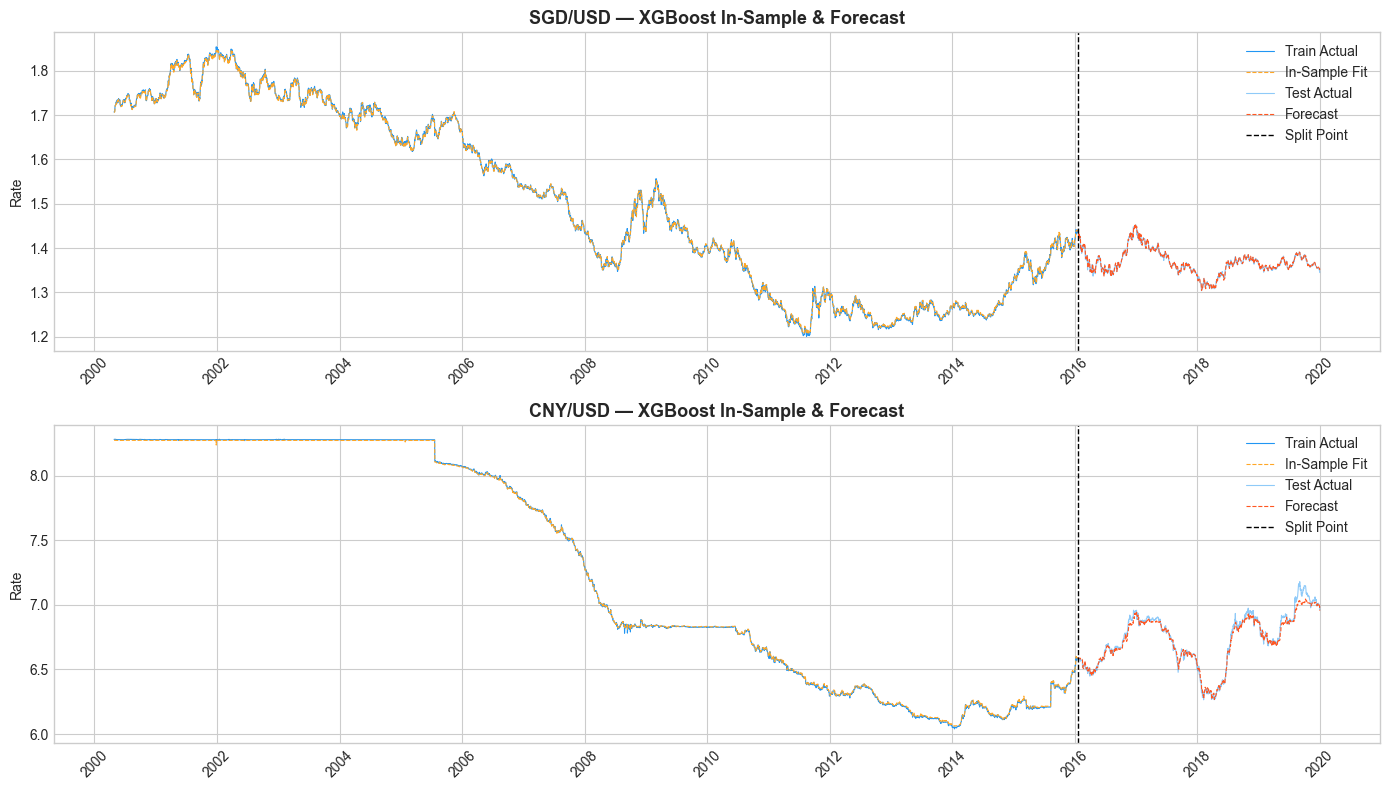

In [112]:
# Plot XGBoost — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train.index, y_train_sgd, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(train.index, xgb_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(test.index, y_test_sgd, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(test.index, xgb_sgd_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — XGBoost In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train.index, y_train_cny, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(train.index, xgb_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(test.index, y_test_cny, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(test.index, xgb_cny_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — XGBoost In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/26_xgboost_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### XGBoost — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.003082 | 0.003743 | 0.006662 | 0.032156 |
| MAE | 0.002392 | 0.002755 | 0.005670 | 0.021963 |
| MAPE | 0.1648% | 0.2014% | 0.0798% | 0.3216% |
| R² | 0.9998 | 0.9817 | 0.9999 | 0.9767 |
| Max Error | 0.017941 | 0.024954 | 0.035263 | 0.147313 |
| Directional Acc. | 68.63% | 59.42% | 53.85% | 55.63% |

**Key findings:**
- **Best SGD R² so far** — 0.9817 out-of-sample, beating all previous models
- **Best SGD RMSE so far** — 0.003743, lower than even the Naïve baseline
- Very small gap between train and test metrics — minimal overfitting
- Directional accuracy drops from 68% train to 59% test for SGD — room for improvement
- CNY performance is excellent across all metrics
- **Conclusion:** XGBoost is the best overall model so far — strong on both 
  level prediction and directional accuracy

### 10.5 LightGBM

LightGBM (Light Gradient Boosting Machine) is similar to XGBoost but uses a 
**leaf-wise tree growth** strategy instead of level-wise. This makes it faster 
to train and more memory efficient — particularly useful for large datasets.

**Key differences from XGBoost:**
- Grows trees leaf-wise rather than level-wise — finds better splits faster
- Uses histogram-based algorithm — bins continuous features for speed
- Generally faster training with comparable or better accuracy

**Key parameters:**
- **n_estimators:** number of boosting rounds
- **max_depth:** maximum tree depth
- **learning_rate:** step size for each boosting round
- **num_leaves:** maximum number of leaves — key parameter for LightGBM
- **subsample:** fraction of data used per iteration

In [114]:
# Fit LightGBM — SGD
lgbm_sgd = LGBMRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgbm_sgd.fit(X_train_scaled, y_train_sgd)

print("✅ LightGBM fitted for SGD")

✅ LightGBM fitted for SGD


In [115]:
# LightGBM SGD — model object output
lgbm_sgd

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [116]:
# Fit LightGBM — CNY
lgbm_cny = LGBMRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgbm_cny.fit(X_train_scaled, y_train_cny)

print("✅ LightGBM fitted for CNY")

✅ LightGBM fitted for CNY


In [117]:
# LightGBM CNY — model object output
lgbm_cny

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [118]:
# LightGBM — in-sample evaluation
lgbm_train_pred_sgd = lgbm_sgd.predict(X_train_scaled)
lgbm_train_pred_cny = lgbm_cny.predict(X_train_scaled)

print("── In-Sample Evaluation ────────────────────────────────")
lgbm_train_sgd_metrics = evaluate_model(y_train_sgd, lgbm_train_pred_sgd, "LightGBM Train — SGD/USD")
print()
lgbm_train_cny_metrics = evaluate_model(y_train_cny, lgbm_train_pred_cny, "LightGBM Train — CNY/USD")

── In-Sample Evaluation ────────────────────────────────
── LightGBM Train — SGD/USD ──────────────────────────────
RMSE               : 0.003073
MAE                : 0.002333
MAPE               : 0.1607%
R²                 : 0.999766
Max Error          : 0.027079
Directional Acc.   : 69.48%

── LightGBM Train — CNY/USD ──────────────────────────────
RMSE               : 0.006590
MAE                : 0.005545
MAPE               : 0.0780%
R²                 : 0.999943
Max Error          : 0.064085
Directional Acc.   : 63.31%


In [119]:
# LightGBM — out-of-sample predictions
lgbm_sgd_pred = lgbm_sgd.predict(X_test_scaled)
lgbm_cny_pred = lgbm_cny.predict(X_test_scaled)

print(f"SGD predictions shape : {lgbm_sgd_pred.shape}")
print(f"CNY predictions shape : {lgbm_cny_pred.shape}")

SGD predictions shape : (1031,)
CNY predictions shape : (1031,)


In [120]:
# LightGBM — evaluate out-of-sample SGD
lgbm_sgd_metrics = evaluate_model(y_test_sgd, lgbm_sgd_pred, "LightGBM — SGD/USD")

── LightGBM — SGD/USD ──────────────────────────────
RMSE               : 0.003717
MAE                : 0.002768
MAPE               : 0.2024%
R²                 : 0.981987
Max Error          : 0.025294
Directional Acc.   : 58.35%


In [121]:
# LightGBM — evaluate out-of-sample CNY
lgbm_cny_metrics = evaluate_model(y_test_cny, lgbm_cny_pred, "LightGBM — CNY/USD")

── LightGBM — CNY/USD ──────────────────────────────
RMSE               : 0.031128
MAE                : 0.023515
MAPE               : 0.3466%
R²                 : 0.978185
Max Error          : 0.126837
Directional Acc.   : 57.48%


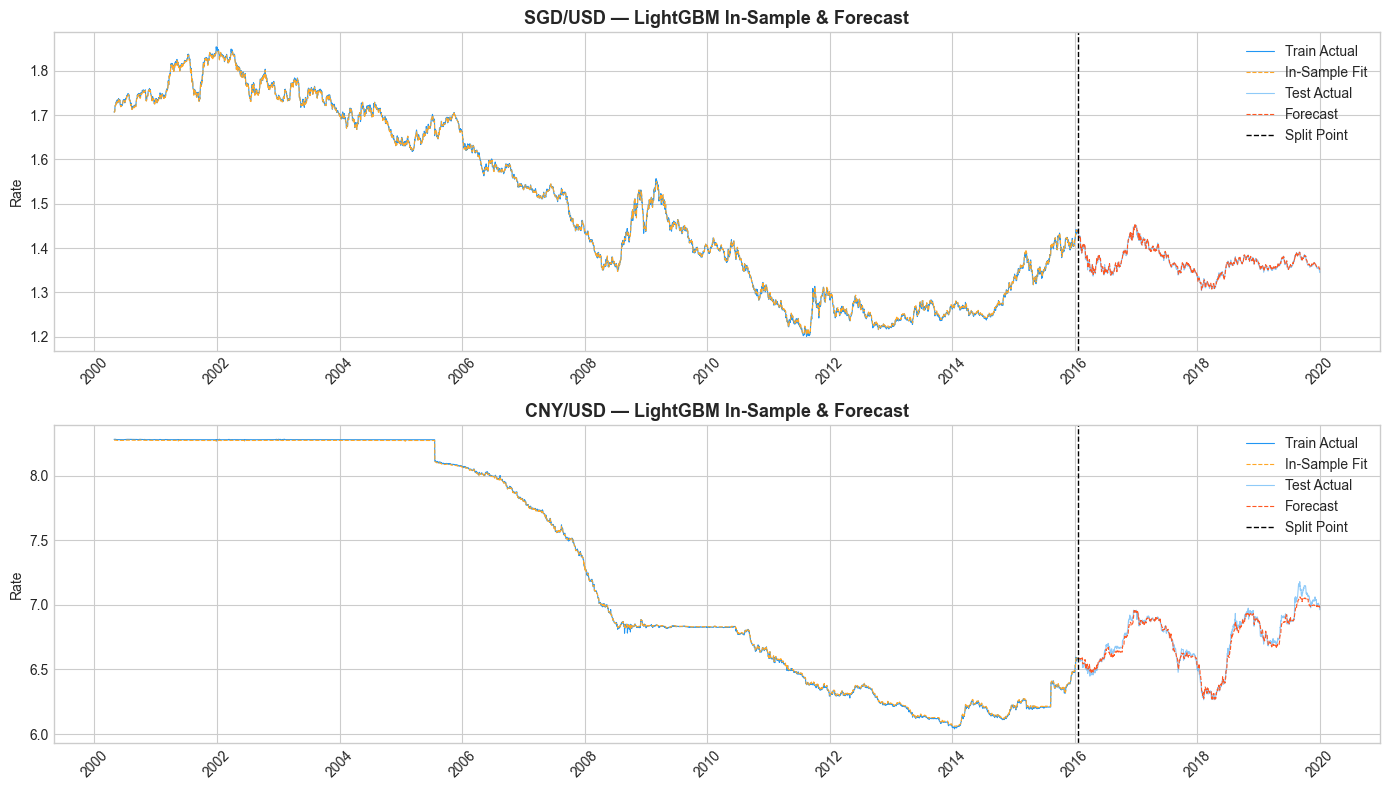

In [122]:
# Plot LightGBM — in-sample and out-of-sample
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(train.index, y_train_sgd, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[0].plot(train.index, lgbm_train_pred_sgd, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[0].plot(test.index, y_test_sgd, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[0].plot(test.index, lgbm_sgd_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[0].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[0].set_title("SGD/USD — LightGBM In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate")
axes[0].legend()

axes[1].plot(train.index, y_train_cny, color="#2196F3", linewidth=0.8, label="Train Actual")
axes[1].plot(train.index, lgbm_train_pred_cny, color="#FFA726", linewidth=0.8, linestyle="--", label="In-Sample Fit")
axes[1].plot(test.index, y_test_cny, color="#2196F3", linewidth=0.8, alpha=0.5, label="Test Actual")
axes[1].plot(test.index, lgbm_cny_pred, color="#FF5722", linewidth=0.8, linestyle="--", label="Forecast")
axes[1].axvline(test.index.min(), color="black", linestyle="--", linewidth=1, label="Split Point")
axes[1].set_title("CNY/USD — LightGBM In-Sample & Forecast", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("./reports/27_lightgbm_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### LightGBM — Results

| Metric | SGD Train | SGD Test | CNY Train | CNY Test |
|---|---|---|---|---|
| RMSE | 0.003073 | 0.003717 | 0.006590 | 0.031128 |
| MAE | 0.002333 | 0.002768 | 0.005545 | 0.023515 |
| MAPE | 0.1607% | 0.2024% | 0.0780% | 0.3466% |
| R² | 0.9998 | 0.9820 | 0.9999 | 0.9782 |
| Max Error | 0.027079 | 0.025294 | 0.064085 | 0.126837 |
| Directional Acc. | 69.48% | 58.35% | 63.31% | 57.48% |

**Key findings:**
- LightGBM and XGBoost perform almost identically — confirming the robustness of 
  gradient boosting for this task
- LightGBM marginally beats XGBoost on CNY R² (0.9782 vs 0.9767)
- XGBoost marginally beats LightGBM on SGD directional accuracy (59.42% vs 58.35%)
- Both gradient boosting models significantly outperform Decision Tree, Random Forest 
  and all statistical models on level prediction
- **Conclusion:** LightGBM and XGBoost are the best ML models — 
  deep learning models in notebook 03 will attempt to improve further

## 10.6 Machine Learning Models — Summary

All 5 ML models have been evaluated. Key findings:

| Model | SGD R² | CNY R² | SGD DA% | CNY DA% | SGD RMSE |
|---|---|---|---|---|---|
| Decision Tree | 0.9218 | 0.9571 | 11.17% | 13.88% | 0.007745 |
| Random Forest | 0.9639 | 0.9561 | 37.48% | 36.89% | 0.005260 |
| SVR | 0.6010 | 0.9621 | 68.06% | 67.28% | 0.017491 |
| XGBoost | 0.9817 | 0.9767 | 59.42% | 55.63% | 0.003743 |
| LightGBM | 0.9820 | 0.9782 | 58.35% | 57.48% | 0.003717 |

**Overall conclusions:**
- XGBoost and LightGBM are the best models for **rate level prediction** (R² and RMSE)
- SVR is the best model for **directional accuracy** (68% SGD, 67% CNY)
- Decision Tree has poor directional accuracy despite decent R²
- ML models significantly outperform all statistical models on level prediction
- Deep learning models in notebook 03 will attempt to capture temporal 
  dependencies that tree-based models cannot